# STUDENT PERFORMANCE PREDICTION
# Data Preprocessing & Feature Engineering

In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/redheadcoffee/student-performance-prediction-synthetic-dataset/student_performance_synthetic_clean.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/redheadcoffee/student-performance-prediction-synthetic-dataset/student_performance_synthetic_clean.csv"
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2000, 13)


,StudentID,Name,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,FinalExamMarks
0,STU10001,Allison Hill,23,Male,88.60,7.78,85.35,53.76,67.11,Yes,1,Medium,68.20
1,STU10002,Noah Rhodes,20,Female,84.17,20.28,65.60,59.41,52.96,Yes,0,Low,52.83
2,STU10003,Angie Henderson,21,Female,84.84,18.51,62.42,62.05,59.86,No,2,Medium,65.05
3,STU10004,Daniel Wagner,23,Female,64.34,9.96,62.85,54.59,49.67,No,1,Medium,48.23
4,STU10005,Cristian Santos,19,Female,90.12,22.43,62.21,76.58,70.07,No,0,Medium,68.26


Initial validation

In [4]:
print("Shape:", df.shape)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate Student IDs:")
print(df["StudentID"].duplicated().sum())

print("\nData types:")
display(df.dtypes)

Shape: (2000, 13)

Missing values:


StudentID                    0
Name                         0
Age                          0
Gender                       0
AttendancePct                0
StudyHoursPerWeek            0
PreviousGrade                0
AssignmentMarks              0
InternalAssessmentMarks      0
OnlineClasses                0
ExtracurricularActivities    0
ParentalSupport              0
FinalExamMarks               0
dtype: int64


Duplicate rows:
0

Duplicate Student IDs:
0

Data types:


StudentID                     object
Name                          object
Age                            int64
Gender                        object
AttendancePct                float64
StudyHoursPerWeek            float64
PreviousGrade                float64
AssignmentMarks              float64
InternalAssessmentMarks      float64
OnlineClasses                 object
ExtracurricularActivities      int64
ParentalSupport               object
FinalExamMarks               float64
dtype: object

Define modelling roles

In [5]:
id_cols = [
    "StudentID",
    "Name"
]

target_col = "FinalExamMarks"

base_features = [
    "Age",
    "Gender",
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "OnlineClasses",
    "ExtracurricularActivities",
    "ParentalSupport"
]

# Feature engineering

Continuous assessment average

In [6]:
df["ContinuousAssessmentAverage"] = (
    df["AssignmentMarks"] +
    df["InternalAssessmentMarks"]
) / 2

Academic history score

In [7]:
df["AcademicHistoryScore"] = (
    df["PreviousGrade"] +
    df["ContinuousAssessmentAverage"]
) / 2

Attendance–study interaction

In [8]:
df["AttendanceStudyInteraction"] = (
    df["AttendancePct"] *
    df["StudyHoursPerWeek"]
)

In [9]:
engineered_features = [
    "ContinuousAssessmentAverage",
    "AcademicHistoryScore",
    "AttendanceStudyInteraction"
]

# checking whether the engineered features make sense

In [10]:
analysis_cols = [
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "ContinuousAssessmentAverage",
    "AcademicHistoryScore",
    "AttendanceStudyInteraction",
    "FinalExamMarks"
]

display(
    df[analysis_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
AttendancePct,2000.0,77.716050,9.980394,47.920,70.810000,77.67000,84.352500,100.0000
StudyHoursPerWeek,2000.0,19.863815,5.926751,5.000,15.985000,19.88000,23.942500,38.6800
PreviousGrade,2000.0,69.912330,9.419616,38.430,63.567500,69.73000,76.412500,95.0000
AssignmentMarks,2000.0,64.115615,10.886810,29.310,57.000000,64.17000,71.215000,99.2300
InternalAssessmentMarks,2000.0,62.387625,9.039026,32.290,56.187500,62.29500,68.330000,92.1800
ContinuousAssessmentAverage,2000.0,63.251620,9.329188,35.480,57.126250,63.13000,69.221250,93.2050
AcademicHistoryScore,2000.0,66.581975,8.884145,38.525,60.595000,66.39250,72.580625,94.1025
AttendanceStudyInteraction,2000.0,1545.343240,511.281316,270.650,1198.458975,1515.11945,1878.660150,3435.0000
FinalExamMarks,2000.0,61.987645,9.611301,31.390,55.537500,62.13000,68.487500,92.8400


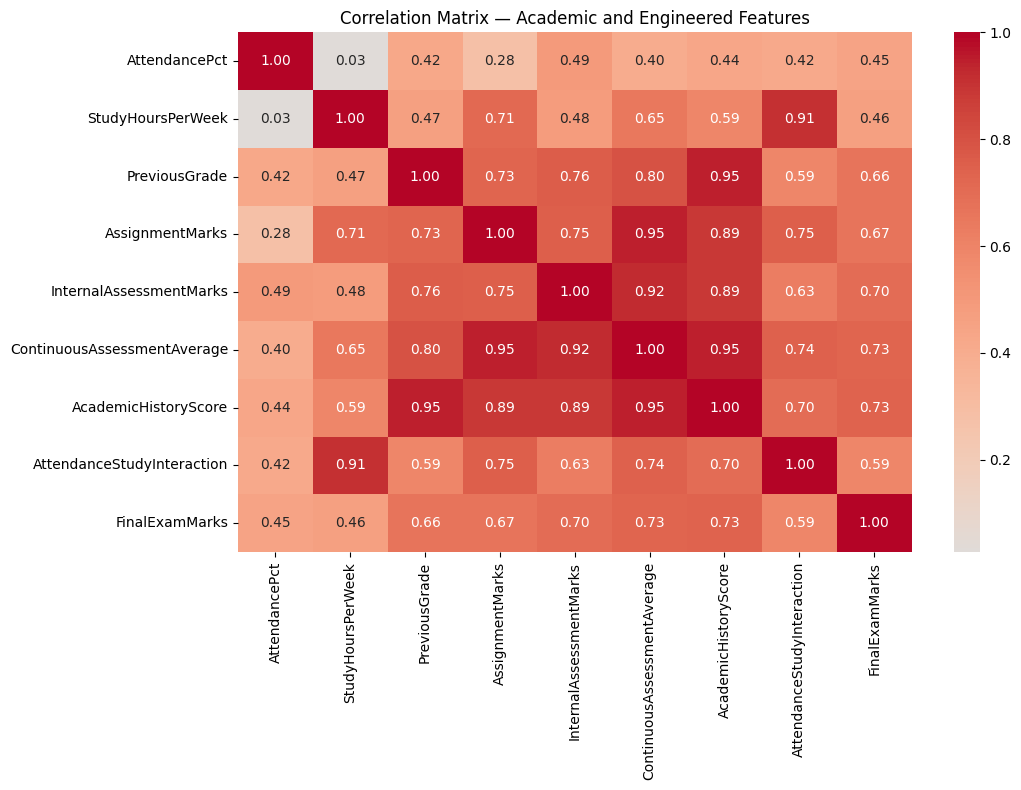

In [11]:
corr = df[analysis_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Academic and Engineered Features")
plt.tight_layout()
plt.show()

In [12]:
output_path = "/kaggle/working/student_performance_feature_engineered.csv"

df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: /kaggle/working/student_performance_feature_engineered.csv
